## Project 2: Legislator Co-Voting 2-Node Network Data

Brandon Chung 3/22/2026

## Instructions

1. Identify a large 2-node network dataset—you can start with a dataset in a repository.  Your data should meet the criteria that it consists of ties between and not within two (or more) distinct groups.
2. Reduce the size of the network using a method such as the island method described in chapter 4 of social network analysis.
3. What can you infer about each of the distinct groups?

For this project I have identified a bipartite dataset from https://voteview.com/data which contains legislators (House members only, identified by icpsr number) and their votes (yay, nay, or abstane) per roll-call. The dataset contains 537,144 observations of votes over 1,235 roll-calls for the 118th congress (2023 - 2025). 

The source for this network data also provides member attributes per legislator including party affiliation and birth year. Exploring this data I will attempt to identify if there are any significant political party or age-based differences for voting behavior. 

Vote View is operated by UCLA's Political Science department and source repository can be found here: https://github.com/voteview/WebVoteView

Citation:

Lewis, Jeffrey B., Keith Poole, Howard Rosenthal, Adam Boche, Aaron Rudkin, and Luke Sonnet (2026). Voteview: Congressional Roll-Call Votes Database. https://voteview.com/

In [1]:
import pandas as pd

votes = pd.read_csv(r"C:\Users\chung\School\620 Web Analytics\Project 2\H118_votes.csv")

# members contains attribute variables for each legislator
members = pd.read_csv(r"C:\Users\chung\School\620 Web Analytics\Project 2\H118_members.csv")


In [2]:
# Preprocessing the data

# Removing columns not needed
votes = votes.drop(columns=['congress', 'chamber', 'prob'])

# Renaming cast_code to vote and replacing cast_codes to Yes or No to signal type of vote
votes = votes.rename(columns={'cast_code': 'vote'})

votes['vote'] = votes['vote'].replace({
    1: 'Yes',
    2: 'Yes',
    3: 'Yes',
    4: 'No',
    5: 'No',
    6: 'No'
})

# Keeping only observations where vote is Yes or No
votes = votes[votes['vote'].isin(['Yes', 'No'])]

# Converting Yes to 1 and No to 0 for edges where legislators support the specific roll call

votes['vote'] = votes['vote'].replace({
    'Yes': 1,
    'No': 0
})


C:\Users\chung\AppData\Local\Temp\ipykernel_476700\2396924266.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  votes['vote'] = votes['vote'].replace({


In [3]:
votes.head()

,rollnumber,icpsr,vote
0,1,14854,0
1,1,14863,0
2,1,14873,1
3,1,15029,1
4,1,15433,1


## Building the bipartite graph

In [4]:
import networkx as nx

G = nx.Graph()

# Identifying two node sets
legislators = votes['icpsr'].unique()
rollcalls = votes['rollnumber'].unique()

# Add legislator nodes
G.add_nodes_from(legislators, bipartite='legislator')

# Add roll call vote nodes
G.add_nodes_from(rollcalls, bipartite='rollcall')

# Add edges 
for _, row in votes.iterrows():
    G.add_edge(row['icpsr'], row['rollnumber'], vote=row['vote'])


In [5]:
list(G.edges(data=True))[:10]


[(np.int64(14854), np.int64(1), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(2), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(3), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(4), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(5), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(6), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(7), {'vote': np.int64(1)}),
 (np.int64(14854), np.int64(8), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(9), {'vote': np.int64(0)}),
 (np.int64(14854), np.int64(10), {'vote': np.int64(0)})]

In [6]:
# Creating biadjacency matrix

from networkx.algorithms import bipartite
from networkx.algorithms.bipartite.matrix import biadjacency_matrix


legislators = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'legislator']
rollcalls = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'rollcall']

M = biadjacency_matrix(
    G,
    row_order=legislators,
    column_order=rollcalls,
    weight='vote'   
)

M_df = pd.DataFrame(
    M.toarray(),
    index=legislators,
    columns=rollcalls
)

M_df.head()


,1,2,3,4,5,6,7,8,9,10,...,1226,1227,1228,1229,1230,1231,1232,1233,1234,1235
14854,0,0,0,0,0,0,1,0,0,0,...,0,1,1,1,1,1,1,1,1,1
14863,0,0,0,0,0,0,1,0,0,0,...,0,1,1,1,1,1,1,1,1,1
14873,1,1,1,1,1,1,0,1,1,1,...,0,0,1,1,1,1,1,1,0,1
15029,1,1,1,1,1,1,0,1,1,1,...,1,0,1,1,1,1,1,1,0,1
15433,1,1,1,1,1,1,0,1,1,1,...,1,0,1,1,1,1,1,1,0,1


In [7]:
# Preprocessing members dataframe for targeted variables party_code and approximate age

# Keeping only necessary columns
members = members[['icpsr', 'party_code', 'born']]

# Converting born (year born) to age in 2024 (mid point of 118th congress)
members = members.rename(columns={'born': 'age'})
members['age'] = 2024 - members['age']


In [8]:
members.head()

,icpsr,party_code,age
0,20301,200,66
1,21102,100,59
2,21500,200,70
3,22108,200,66
4,22140,200,58


In [9]:
# Converting members df to dictionary to add attributes to nodes

member_dict = members.set_index('icpsr').to_dict('index')

for icpsr, attrs in member_dict.items():
    if icpsr in G.nodes:
        nx.set_node_attributes(G, {icpsr: attrs})

In [10]:
# Sanity Check
G.nodes[20301]

{'bipartite': 'legislator', 'party_code': 200, 'age': 66}

## Weighted Projection of Legislator - Legislator 

In [11]:
import numpy as np

# Converting biadjacency matrix to array
M = M_df.to_numpy()

# Legislator–legislator weighted similarity matrix
W = M @ M.T

# Converting to df
W_df = pd.DataFrame(W, index=M_df.index, columns=M_df.index)

G_leg = nx.Graph()

for i, leg_i in enumerate(W_df.index):
    for j, leg_j in enumerate(W_df.index):
        if i < j and W_df.iloc[i, j] > 0:
            G_leg.add_edge(leg_i, leg_j, weight=W_df.iloc[i, j])

# Attaching attributes

nx.set_node_attributes(G_leg, member_dict)


In [12]:
list(G_leg.edges(data=True))[:10]

[(14854, 14863, {'weight': np.int64(693)}),
 (14854, 14873, {'weight': np.int64(258)}),
 (14854, 15029, {'weight': np.int64(299)}),
 (14854, 15433, {'weight': np.int64(233)}),
 (14854, 15448, {'weight': np.int64(215)}),
 (14854, 15454, {'weight': np.int64(262)}),
 (14854, 15616, {'weight': np.int64(235)}),
 (14854, 20104, {'weight': np.int64(241)}),
 (14854, 20107, {'weight': np.int64(710)}),
 (14854, 20119, {'weight': np.int64(267)})]

## Island Method Reduction on Weighted Projection

In [13]:
# 75th percentile of edge weights

weights = [d['weight'] for _,_,d in G_leg.edges(data=True)]
threshold = np.percentile(weights, 75)
threshold


np.float64(470.0)

In [14]:
island_edges = [
    (u, v) for u, v, d in G_leg.edges(data=True)
    if d['weight'] >= threshold
]

G_island = G_leg.edge_subgraph(island_edges).copy()

# Attaching attibutes to island network
nx.set_node_attributes(G_island, member_dict)

G_island.number_of_nodes(), G_island.number_of_edges()

(326, 25462)

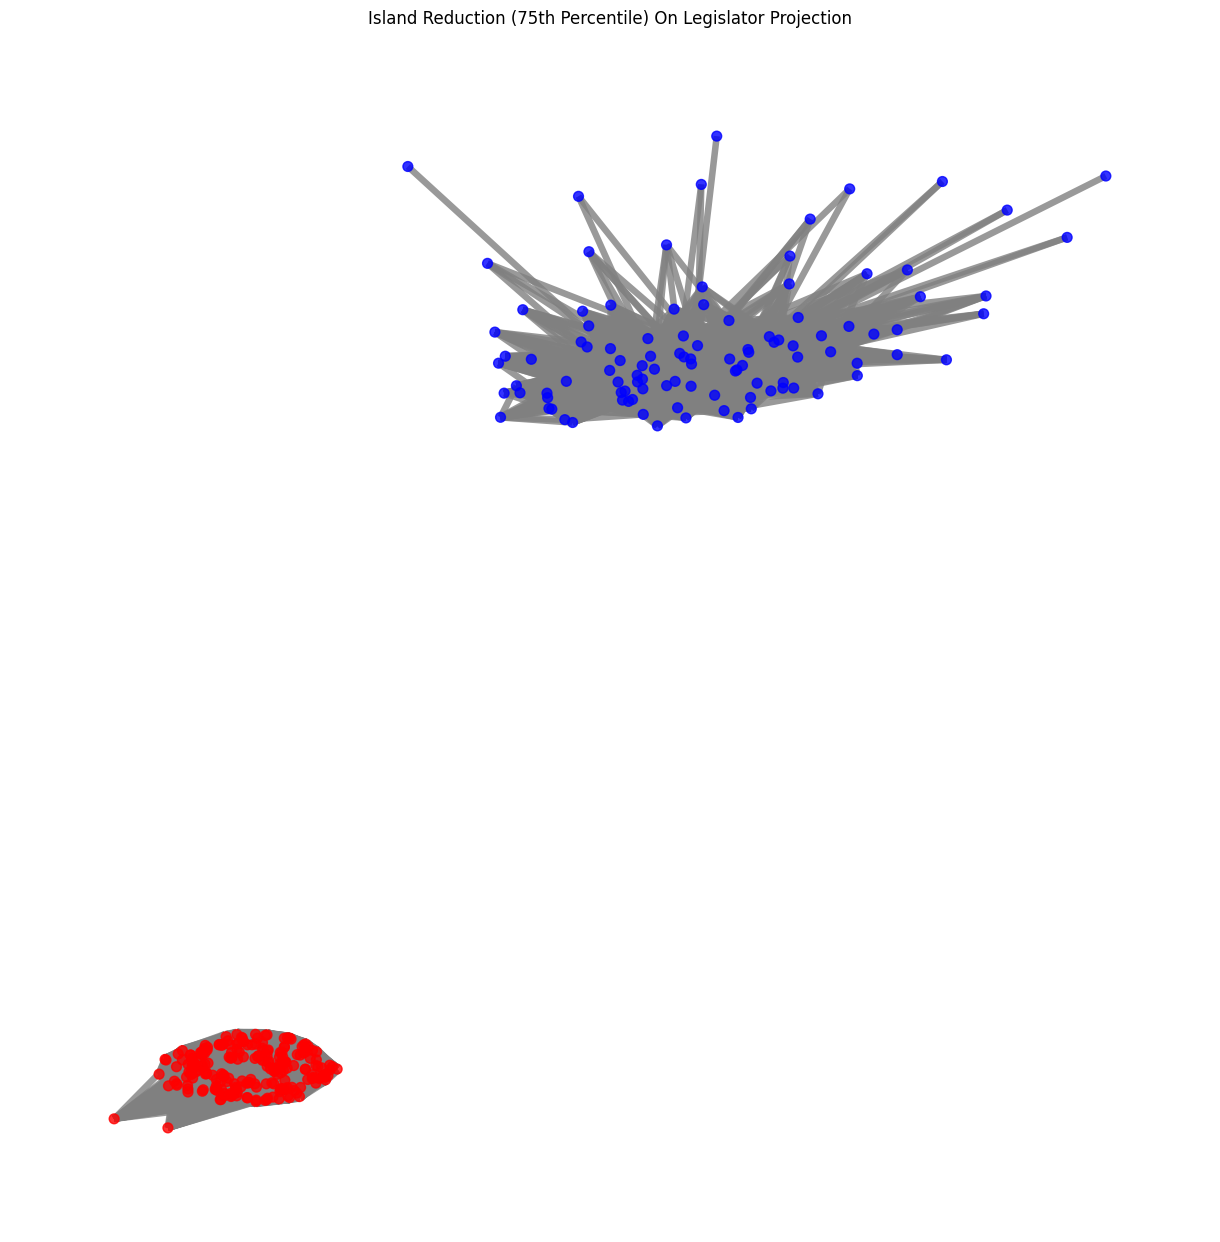

In [16]:
import matplotlib.pyplot as plt
# Visualizing island subgraph
plt.figure(figsize=(12, 12))

pos = nx.spring_layout(G_island, k=0.2, iterations=50)

nx.draw(
    G_island,
    pos,
    node_size=50,
    node_color=[
        'red' if G_island.nodes[n]['party_code'] == 200 else 'blue'
        for n in G_island.nodes()
    ],
    edge_color='gray',
    width=[d['weight']/100 for _,_,d in G_island.edges(data=True)],
    alpha=0.8,
    with_labels=False
)

plt.title("Island Reduction (75th Percentile) On Legislator Projection")
plt.show()


In [17]:
pd.Series([G_island.nodes[n]['party_code'] for n in G_island.nodes()]).value_counts()

200    219
100    107
Name: count, dtype: int64

Using the island method of network reduction I choose the 75th percentile to visualize our covoting graph. I found that at the 80th percentile and above only republican legislators were represented. This indicates that republican law makers vote more uniformly than Democrats. We can note that the cluster of republican nodes are more tightly clustered when compared to the Democrat nodes, and in addition, the clear gap in-between the two groups means that if legislators from each party vote with eachother, those events are not frequent enough to show with our island reduction threshold. 

## Statistical Testing for Differences by Age and Political Party 

In [18]:
# Calculating centrality metrics

deg_cent = nx.degree_centrality(G_leg)
bet_cent = nx.betweenness_centrality(G_leg, weight='weight', normalized=True)
eig_cent = nx.eigenvector_centrality(G_leg, weight='weight', max_iter=500)

# Converting metrics into a df
cent_df = pd.DataFrame({
    'icpsr': list(G_leg.nodes()),
    'degree': [deg_cent[n] for n in G_leg.nodes()],
    'betweenness': [bet_cent[n] for n in G_leg.nodes()],
    'eigenvector': [eig_cent[n] for n in G_leg.nodes()]
})

# Merge in age and party

members_sub = members[['icpsr', 'age', 'party_code']]
cent_df = cent_df.merge(members_sub, on='icpsr', how='left')


In [19]:
cent_df.head()

,icpsr,degree,betweenness,eigenvector,age,party_code
0,14854,1.0,0.0,0.055353,87,200
1,14863,1.0,0.0,0.058977,71,200
2,14873,1.0,0.0,0.030489,85,100
3,15029,1.0,0.0,0.034878,78,100
4,15433,1.0,0.0,0.029962,76,100


In [20]:
# Using Mann Whitney U test for differences in centrality metrics by party

from scipy.stats import mannwhitneyu

# Split by party
dem = cent_df[cent_df['party_code'] == 100]
rep = cent_df[cent_df['party_code'] == 200]

# Degree centrality
u_deg, p_deg = mannwhitneyu(dem['degree'], rep['degree'], alternative='two-sided')

# Betweenness centrality
u_bet, p_bet = mannwhitneyu(dem['betweenness'], rep['betweenness'], alternative='two-sided')

# Eigenvector centrality
u_eig, p_eig = mannwhitneyu(dem['eigenvector'], rep['eigenvector'], alternative='two-sided')

print("Mann–Whitney U Test Results (Democrats vs Republicans)")
print("------------------------------------------------------")
print(f"Degree centrality:     U = {u_deg:.2f}, p = {p_deg:.4f}")
print(f"Betweenness centrality: U = {u_bet:.2f}, p = {p_bet:.4f}")
print(f"Eigenvector centrality: U = {u_eig:.2f}, p = {p_eig:.4f}")


Mann–Whitney U Test Results (Democrats vs Republicans)
------------------------------------------------------
Degree centrality:     U = 25583.00, p = 0.7793
Betweenness centrality: U = 25684.00, p = 0.5672
Eigenvector centrality: U = 2218.00, p = 0.0000


The Mann-Whitney U Test results show no differences between Democrats and Rebuplicans for degree and betweenness centrality, indicating that both parties have similar numbers of co-voting ties and bridging individuals within each party. Eigenvector centrality, however, differed sharply - Republicans form a more influential core with highly connected legislators connecting with other highly connected legislators. The Republican core legislators likely either plan and vote together strategically or hold very similar ideologies which lend toward similar voting habits. 

In [21]:
# Using Mann Whitney U test for differences in centrality metrics by age

# Splitting legislators into younger and older groups by medican age

median_age = cent_df['age'].median()

younger = cent_df[cent_df['age'] < median_age]
older   = cent_df[cent_df['age'] >= median_age]


# Degree centrality
u_deg_age, p_deg_age = mannwhitneyu(younger['degree'], older['degree'], alternative='two-sided')

# Betweenness centrality
u_bet_age, p_bet_age = mannwhitneyu(younger['betweenness'], older['betweenness'], alternative='two-sided')

# Eigenvector centrality
u_eig_age, p_eig_age = mannwhitneyu(younger['eigenvector'], older['eigenvector'], alternative='two-sided')

print("Mann–Whitney U Test Results (Younger vs Older Legislators)")
print("----------------------------------------------------------")
print(f"Degree centrality:      U = {u_deg_age:.2f}, p = {p_deg_age:.4f}")
print(f"Betweenness centrality: U = {u_bet_age:.2f}, p = {p_bet_age:.4f}")
print(f"Eigenvector centrality: U = {u_eig_age:.2f}, p = {p_eig_age:.4f}")


Mann–Whitney U Test Results (Younger vs Older Legislators)
----------------------------------------------------------
Degree centrality:      U = 25716.50, p = 0.5934
Betweenness centrality: U = 25686.00, p = 0.5386
Eigenvector centrality: U = 26801.00, p = 0.3103


Mann–Whitney U tests comparing younger and older legislators revealed no significant differences in degree centrality (p = 0.5934), betweenness centrality (p = 0.5386), or eigenvector centrality (p = 0.3103). These results indicate that age is not associated with the number of co‑voting ties, brokerage positions, or embeddedness within the core of the co‑voting network. Unlike the strong party differences observed in eigenvector centrality, age does not appear to structure legislators’ positions within the network, suggesting that ideological cohesion and influence are driven primarily by party rather than seniority.

## Conclusion

In conclusion, combined evidence from the island reduced weighted projection and the statistical testing reveals that co-voting structure is shaped far more by party affiliation than by legislator age. Our weighted legislator - legislator projection produced two clearly seperated clusters with each political party forming distinct communities and no cross party ties at the 75th percentile tie weight. 

The Mann-Whitney U tests confirmed this and showed no significant differences between Democrats and Republicans in centrality metrics. However, parties differed sharply in eigenvector centrality, with republicans exhibiting significantly higher scores. Republicans form a more tightly connected core community and show greater party unity. In contrast, age showed no significant relationship with any centrality metric. Seniority did not translate into greater embeddedness or influence.

Taken together, the network visualization and statistical analyses paint a coherent picture: the structure of legislative co‑voting is dominated by partisan alignment, producing two polarized and internally cohesive communities, while age plays little to no role in shaping legislators’ structural positions.

Video Presentation: https://youtu.be/9Ams-NuJRAI